# Project: Predicting House Prices with Linear Regression

## Analysis Objective

This data analysis report aims to conduct linear regression analysis based on existing house sale prices and their corresponding attributes. The resulting linear regression model will then be used to predict the price of the following house with unknown sale price based on its attributes:

**House Features:**
- Area: 6,500 square feet
- Bedrooms: 4
- Bathrooms: 2
- Total Floors: 2
- Not located on the main road
- No guest room
- With basement
- With water heater
- No air conditioning
- Parking spaces: 2
- Located in the city's preferred neighborhood
- Simple level of decoration

## Introduction  
The dataset `house_price.csv` records transaction prices and related attribute information for over five hundred houses. This includes features such as the house area, number of bedrooms, number of bathrooms, number of floors, whether the house is located on the main road, whether it has a guest room, and more.

The `house_price.csv` dataset includes the following columns, with their meanings as described:

- **price**: The sale price of the house.  
- **area**: The area of the house, measured in square feet.  
- **bedrooms**: Number of bedrooms.  
- **bathrooms**: Number of bathrooms.  
- **stories**: Number of floors.  

- **mainroad**: Whether the house is located on a main road.  
  - `yes` – Yes  
  - `no` – No  

- **guestroom**: Whether the house has a guest room.  
  - `yes` – Yes  
  - `no` – No  

- **basement**: Whether the house has a basement.  
  - `yes` – Yes  
  - `no` – No  

- **hotwaterheating**: Whether the house has a hot water heater.  
  - `yes` – Yes  
  - `no` – No  

- **airconditioning**: Whether the house has air conditioning.  
  - `yes` – Yes  
  - `no` – No  

- **parking**: Garage capacity, measured by the number of cars it can hold.  

- **prefarea**: Whether the house is located in the city's preferred neighborhood.  
  - `yes` – Yes  
  - `no` – No  

- **furnishingstatus**: The furnishing status of the house.  
  - `furnished` – Fully furnished  
  - `semi‑furnished` – Semi‑furnished  
  - `unfurnished` – Unfurnished

## Loading Data

Import the necessary libraries for data analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import the necessary libraries for data analysis and use Pandas' `read_csv` function to parse the data from the raw data file "house_price.csv" into a DataFrame, assigning it to the variable `original_house_price`.

In [ ]:
original_house_price = pd.read_csv(r"C:\Users\小穆\Desktop\林粒粒python项目实战\项目 89 房价预测\house_price(1).csv")
original_house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Data Assessment and Cleaning

In this section, we will evaluate and clean the data contained in the `original_house_price` DataFrame that was created in the previous part.

The assessment will primarily focus on two aspects: **structure** and **content** — that is, tidiness and cleanliness.

- **Structural issues** refer to deviations from the three standards: each variable forms a column, each observation forms a row, and each type of observational unit forms a table.  
- **Content issues** include missing data, duplicate data, invalid data, and other similar problems.

To distinguish between the cleaned data and the original data, we create a new variable `cleaned_house_price` as a copy of `original_house_price`. All subsequent cleaning steps will be applied to `cleaned_house_price`.

In [ ]:
cleaned_house_price = original_house_price.copy()

### Data Tidiness

In [ ]:
cleaned_house_price.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Based on the first 10 rows of data, the dataset conforms to the principles of "each variable as a column, each observation as a row, and each type of observational unit as a table." Therefore, no structural issues exist.

### Data Cleanliness

Next, we'll use the `info` method to gain a general understanding of the data content.

In [ ]:
cleaned_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


From the output, `cleaned_house_price` contains a total of 545 observations, and there are no missing values in the variables.

Regarding data types, we know that `mainroad` (whether located on a main road), `guestroom` (whether it has a guest room), `basement` (whether it has a basement), `hotwaterheating` (whether it has a hot water heater), `airconditioning` (whether it has air conditioning), `prefarea` (whether located in the city's preferred neighborhood), and `furnishingstatus` (furnishing status) are all categorical data. Their data types can be converted to `category`.

In [ ]:
cleaned_house_price['mainroad'] = cleaned_house_price['mainroad'].astype("category")
cleaned_house_price['guestroom'] = cleaned_house_price['guestroom'].astype("category")
cleaned_house_price['basement'] = cleaned_house_price['basement'].astype("category")
cleaned_house_price['hotwaterheating'] = cleaned_house_price['hotwaterheating'].astype("category")
cleaned_house_price['airconditioning'] = cleaned_house_price['airconditioning'].astype("category")
cleaned_house_price['prefarea'] = cleaned_house_price['prefarea'].astype("category")
cleaned_house_price['furnishingstatus'] = cleaned_house_price['furnishingstatus'].astype("category")

In [ ]:
cleaned_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


#### Handling Missing Data

Based on the output of the `info` method, `cleaned_house_price` contains no missing values. Therefore, no handling of missing data is required.

#### Handling Inconsistent Data

A quick overview of numerical statistical information can be obtained using the DataFrame's `describe` method.

In [ ]:
cleaned_house_price.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Based on the statistical information above, there are no unrealistic or out-of-range values in `cleaned_house_price`.

## Exploring the Data

Before proceeding with inferential statistical analysis, we can first use data visualization to explore the distribution of numerical variables and identify variables that correlate with house prices. This will help guide further analysis.

In [ ]:
# Set the chart color palette to "pastel"
sns.set_palette("pastel")

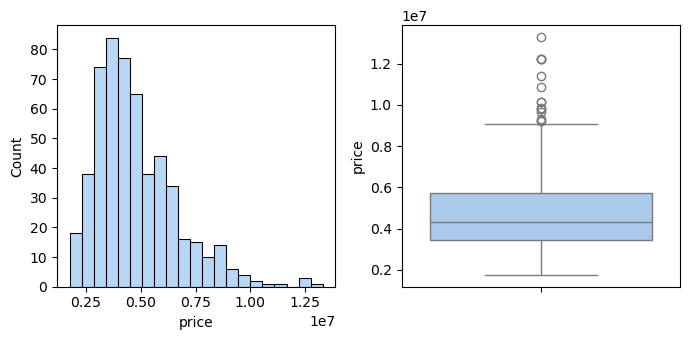

In [ ]:
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='price', ax=axes[0])
sns.boxplot(cleaned_house_price, y='price', ax=axes[1])
plt.show()

House prices exhibit a right‑skewed distribution, indicating that most houses in the dataset are moderately priced, but there are a few high‑priced outliers that pull the mean upward.

### Area Distribution

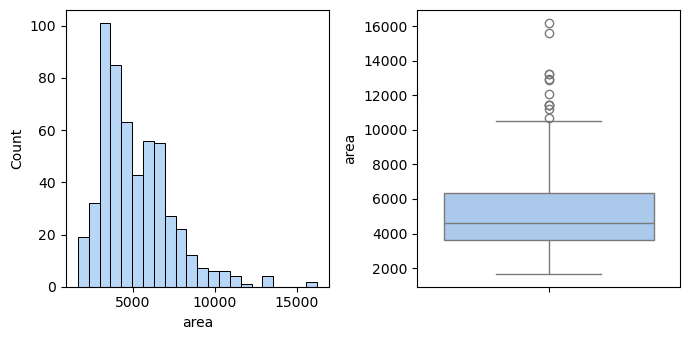

In [ ]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='area', ax=axes[0])
sns.boxplot(cleaned_house_price, y='area', ax=axes[1])
plt.show()

The distribution of area is similar to that of house prices, also showing a right‑skewed pattern.

### Relationship Between House Price and Area

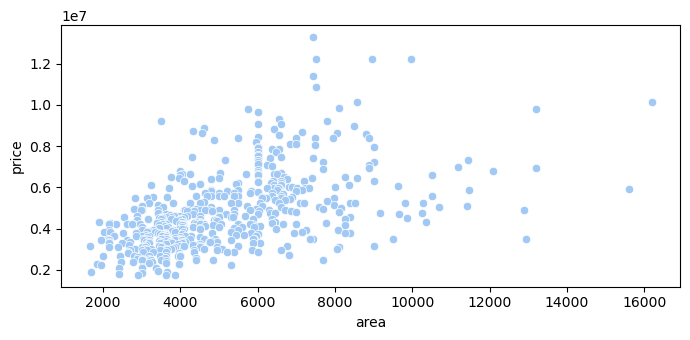

In [ ]:
sns.scatterplot(cleaned_house_price, x='area', y='price')
plt.show()

From the scatter plot, a roughly positive correlation can be observed, but the strength of this relationship needs to be quantified through subsequent correlation calculations.

### Number of Bedrooms vs. House Price

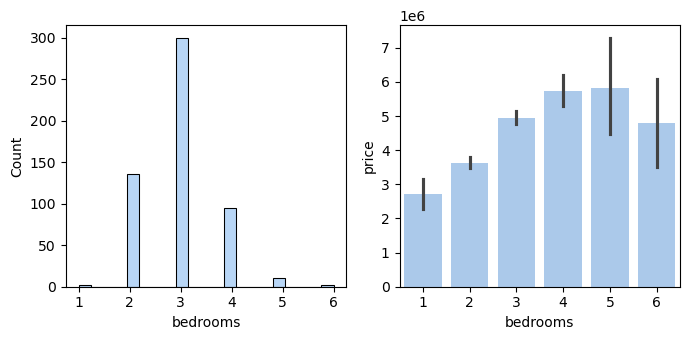

In [ ]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='bedrooms', ax=axes[0])
sns.barplot(cleaned_house_price, x='bedrooms', y='price', ax=axes[1])
plt.show()

In this dataset, the number of bedrooms ranges from 1 to 6, with most houses having 2 to 4 bedrooms.

Based on the bar chart showing average house price by bedroom count, when the number of bedrooms is fewer than 5, houses with more bedrooms generally command higher prices. However, once the number exceeds 5, prices do not consistently increase accordingly.

### Number of Bathrooms vs. House Price

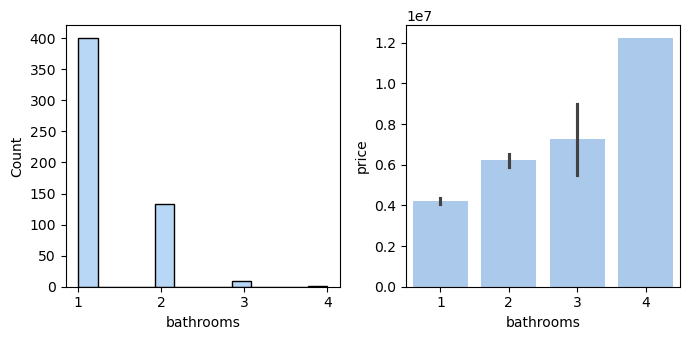

In [ ]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='bathrooms', ax=axes[0])
sns.barplot(cleaned_house_price, x='bathrooms', y='price', ax=axes[1])
plt.show()

The number of bathrooms in the dataset ranges from a minimum of 1 to a maximum of 4, with the majority of houses having 1 bathroom.

Based on the bar chart comparing average house price with the number of bathrooms, houses with more bathrooms generally correspond to higher prices.

### Number of Floors vs. House Price

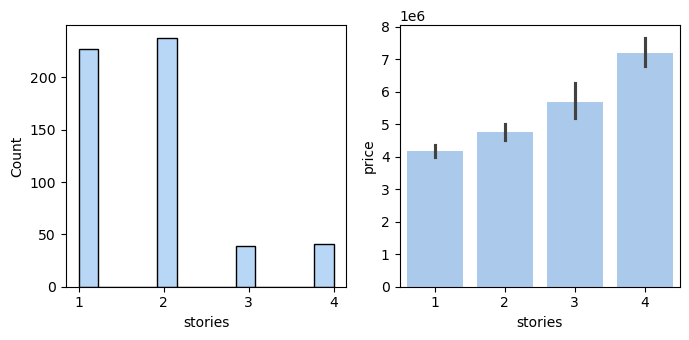

In [ ]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='stories', ax=axes[0])
sns.barplot(cleaned_house_price, x='stories', y='price', ax=axes[1])
plt.show()

In this dataset, the number of floors ranges from 1 to 4, with most houses having either 1 or 2 floors.

Based on the bar chart comparing average house price with the number of floors, houses with more floors generally correspond to higher prices.

### Number of Parking Spaces vs. House Price

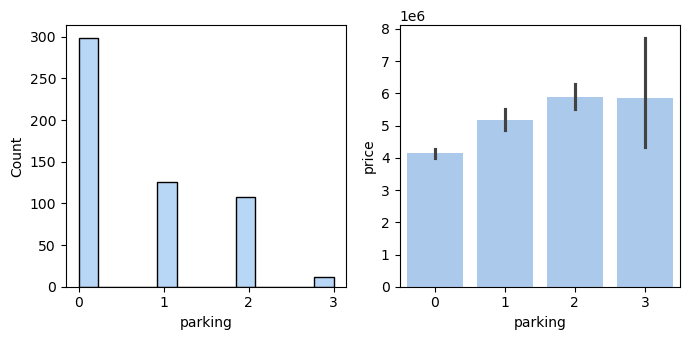

In [ ]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_house_price, x='parking', ax=axes[0])
sns.barplot(cleaned_house_price, x='parking', y='price', ax=axes[1])
plt.show()

In this dataset, the number of parking spaces ranges from 0 to 3. Houses without parking spaces are the most common, followed by those with 1 and 2 spaces.

Based on the bar chart comparing average house price with the number of parking spaces, houses with more parking spaces generally command higher prices. However, once the number exceeds 2, prices do not consistently increase accordingly.

### Location on Main Road vs. House Price

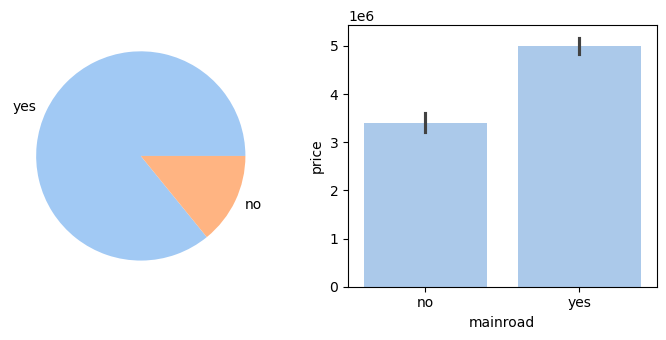

In [ ]:
figure, axes = plt.subplots(1, 2)
mainroad_count = cleaned_house_price['mainroad'].value_counts()
mainroad_label = mainroad_count.index
axes[0].pie(mainroad_count, labels=mainroad_label)
sns.barplot(cleaned_house_price, x='mainroad', y='price', ax=axes[1])
plt.show()

In this dataset, most houses are located on a main road.

Based on the bar chart comparing average house price with location relative to a main road, houses situated on a main road generally correspond to higher prices.

### Presence of Guest Room vs. House Price

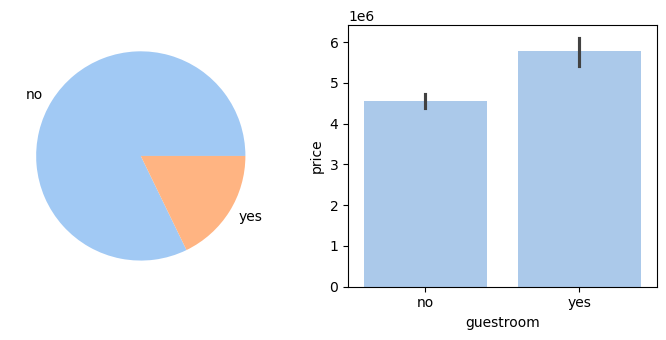

In [ ]:
figure, axes = plt.subplots(1, 2)
guestroom_count = cleaned_house_price['guestroom'].value_counts()
guestroom_label = guestroom_count.index
axes[0].pie(guestroom_count, labels=guestroom_label)
sns.barplot(cleaned_house_price, x='guestroom', y='price', ax=axes[1])
plt.show()

In this dataset, most houses do not have a guest room.

Based on the bar chart comparing average house price with the presence of a guest room, houses that include a guest room generally correspond to higher prices.

### Presence of Basement vs. House Price

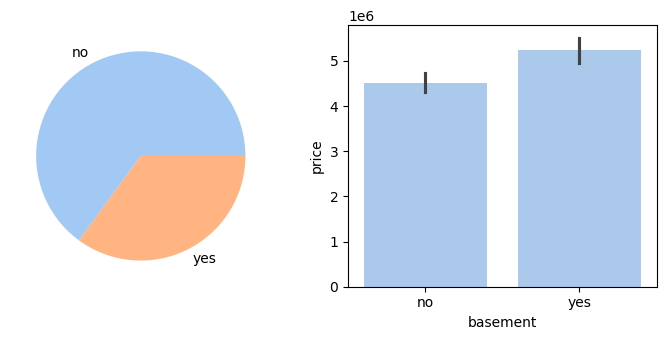

In [ ]:
figure, axes = plt.subplots(1, 2)
basement_count = cleaned_house_price['basement'].value_counts()
basement_label = basement_count.index
axes[0].pie(basement_count, labels=basement_label)
sns.barplot(cleaned_house_price, x='basement', y='price', ax=axes[1])
plt.show()
            

In this dataset, more houses lack a basement.

Based on the bar chart comparing average house price with the presence of a basement, houses that include a basement generally correspond to higher prices.

### Presence of Hot Water Heater vs. House Price

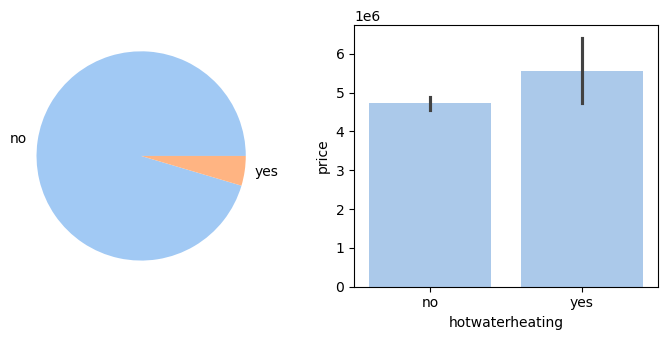

In [ ]:
figure, axes = plt.subplots(1, 2)
hotwaterheating_count = cleaned_house_price['hotwaterheating'].value_counts()
hotwaterheating_label = hotwaterheating_count.index
axes[0].pie(hotwaterheating_count, labels=hotwaterheating_label)
sns.barplot(cleaned_house_price, x='hotwaterheating', y='price', ax=axes[1])
plt.show()

In this dataset, the vast majority of houses do not have a hot water heater.

Based on the bar chart comparing average house price with the presence of a hot water heater, houses equipped with a hot water heater generally correspond to higher prices.

### Presence of Air Conditioning vs. House Price

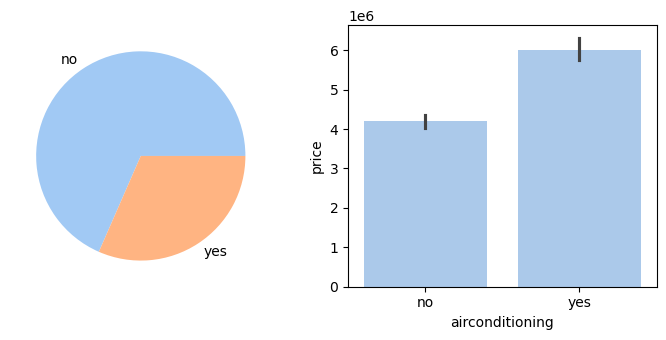

In [ ]:
figure, axes = plt.subplots(1, 2)
airconditioning_count = cleaned_house_price['airconditioning'].value_counts()
airconditioning_label = hotwaterheating_count.index
axes[0].pie(airconditioning_count, labels=airconditioning_label)
sns.barplot(cleaned_house_price, x='airconditioning', y='price', ax=axes[1])
plt.show()

In this dataset, more houses lack air conditioning.

Based on the bar chart comparing average house price with the presence of air conditioning, houses equipped with air conditioning generally correspond to higher prices.

### Location in Preferred Neighborhood vs. House Price

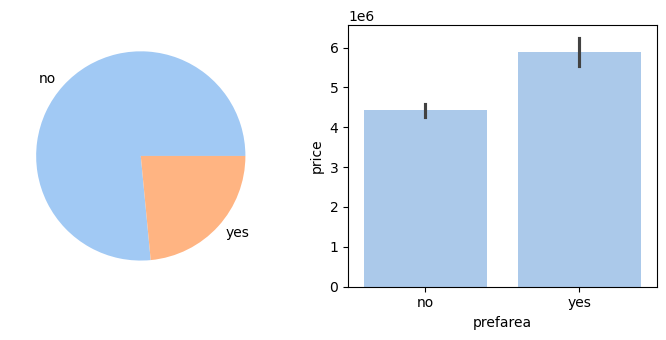

In [ ]:
figure, axes = plt.subplots(1, 2)
prefarea_count = cleaned_house_price['prefarea'].value_counts()
prefarea_label = prefarea_count.index
axes[0].pie(prefarea_count, labels=prefarea_label)
sns.barplot(cleaned_house_price, x='prefarea', y='price', ax=axes[1])
plt.show()

In this dataset, most houses are not located in the city's preferred neighborhood.

Based on the bar chart comparing average house price with location in the preferred neighborhood, houses situated in the preferred neighborhood generally correspond to higher prices.

### Furnishing Status vs. House Price

C:\Users\小穆\AppData\Local\Temp\ipykernel_26472\1726210345.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')


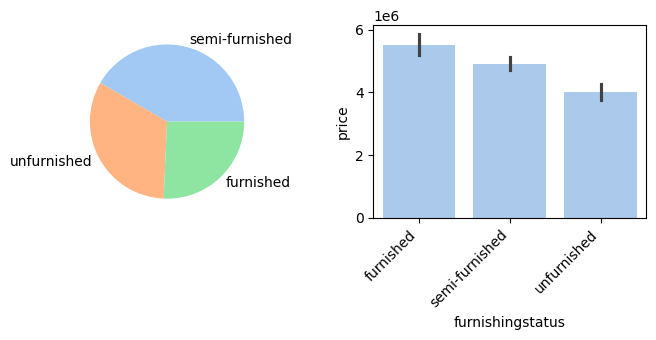

In [ ]:
figure, axes = plt.subplots(1, 2)
furnishingstatus_count = cleaned_house_price['furnishingstatus'].value_counts()
furnishingstatus_label = furnishingstatus_count.index
axes[0].pie(furnishingstatus_count, labels=furnishingstatus_label)
sns.barplot(cleaned_house_price, x='furnishingstatus', y='price', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

In this dataset, semi-furnished and unfurnished houses are more common, with about one-quarter of the houses being furnished.

Based on the bar chart comparing average house price with furnishing status, furnished houses command higher prices than semi-furnished ones, and semi-furnished houses command higher prices than unfurnished ones.

## Analyzing the Data

In [ ]:
cleaned_house_price

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In the analysis step, we will use the data from `cleaned_house_price` to perform linear regression analysis. The goal is to obtain a mathematical model that can predict house prices based on various property attributes.

We will first import the modules required for linear regression.

In [ ]:
import statsmodels.api as sm

Then, we can create a new DataFrame called `lr_house_price` to serve as the data for our linear regression analysis.

The reason for distinguishing it from `cleaned_house_price` is that we may still need to prepare the data before conducting regression analysis—such as creating dummy variables—and these operations can be performed on `lr_house_price`.

In [ ]:
lr_house_price = cleaned_house_price.copy()

In [ ]:
lr_house_price

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


Since there are categorical variables in the data, a linear regression model cannot be built directly. We need to introduce dummy variables, which use 0 and 1 to indicate whether each observation belongs to a particular category.

In [ ]:
lr_house_price = pd.get_dummies(lr_house_price, drop_first=True, columns=['mainroad', 'guestroom',
                                                         'basement', 'hotwaterheating',
                                                         'airconditioning','prefarea', 
                                                         'furnishingstatus'], dtype=int)
lr_house_price

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


Next, we need to separate the dependent variable and the independent variables.

The dependent variable is `price`, because the purpose of performing linear regression is to obtain a model that can predict the sale price based on other variables that may influence house prices.

In [ ]:
y = lr_house_price['price']

We can include all variables except price as independent variables, but we need to examine the correlations among them. If some variables are highly correlated with each other, it may lead to multicollinearity.

In [ ]:
X = lr_house_price.drop('price', axis=1)

Generally, it is considered that when the absolute value of the correlation coefficient exceeds 0.8, it may lead to severe multicollinearity. Therefore, when examining correlations, we only need to look for values with an absolute value greater than 0.8.

In [ ]:
X.corr().abs() > 0.8

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
area,True,False,False,False,False,False,False,False,False,False,False,False,False
bedrooms,False,True,False,False,False,False,False,False,False,False,False,False,False
bathrooms,False,False,True,False,False,False,False,False,False,False,False,False,False
stories,False,False,False,True,False,False,False,False,False,False,False,False,False
parking,False,False,False,False,True,False,False,False,False,False,False,False,False
mainroad_yes,False,False,False,False,False,True,False,False,False,False,False,False,False
guestroom_yes,False,False,False,False,False,False,True,False,False,False,False,False,False
basement_yes,False,False,False,False,False,False,False,True,False,False,False,False,False
hotwaterheating_yes,False,False,False,False,False,False,False,False,True,False,False,False,False
airconditioning_yes,False,False,False,False,False,False,False,False,False,True,False,False,False


From the output above, the absolute values of the correlation coefficients between different variables are all less than or equal to 0.8. 

Next, add an intercept to the linear equation of the model.

In [ ]:
X = sm.add_constant(X)
X

,const,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,1.0,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,1.0,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,1.0,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,1.0,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1.0,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1.0,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1.0,2910,3,1,1,0,0,0,0,0,0,0,0,0


Next, we can call the OLS function and use the ordinary least squares method to obtain the parameter values of the linear regression model.

In [ ]:
model = sm.OLS(y, X).fit()

To view the model results, we use the `summary` method to obtain the summary information.

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Sat, 28 Feb 2026   Prob (F-statistic):          9.07e-123
Time:                        18:40:25   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
mainroad_yes                     4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom_yes                    3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement_yes                     3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating_yes              8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning_yes               8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
prefarea_yes                     6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:

equation = f"Price = {model.params[0]:.4f}"
for i, col in enumerate(X.columns[1:]):
    equation += f" + ({model.params[i+1]:.4f}) * {col}"
print(equation)

Price = 42771.6939 + (244.1394) * area + (114787.5602) * bedrooms + (987668.1073) * bathrooms + (450848.0029) * stories + (277107.1013) * parking + (421272.5887) * mainroad_yes + (300525.8596) * guestroom_yes + (350106.9041) * basement_yes + (855447.1454) * hotwaterheating_yes + (864958.3113) * airconditioning_yes + (651543.7999) * prefarea_yes + (-46344.6200) * furnishingstatus_semi-furnished + (-411234.3862) * furnishingstatus_unfurnished


C:\Users\小穆\AppData\Local\Temp\ipykernel_26472\413451303.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  equation = f"Price = {model.params[0]:.4f}"
C:\Users\小穆\AppData\Local\Temp\ipykernel_26472\413451303.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  equation += f" + ({model.params[i+1]:.4f}) * {col}"


When we set the significance level at 0.05, the p-values in the results above indicate that the model considers the following factors to have no significant impact on house prices: number of bedrooms, and whether the house is semi-furnished. Additionally, the p-value for the constant term (representing the intercept of the linear equation) is also large, indicating no significant effect.

These variables can be removed before building a new linear regression model.

In [ ]:
X = X.drop(['const', 'bedrooms', 'furnishingstatus_semi-furnished'], axis=1)

In [ ]:
model = sm.OLS(y, X).fit()

In [ ]:
model.summary()

Based on the coefficients of each independent variable in the linear regression equation, the model predicts that the following factors significantly increase house prices: house area, number of bathrooms, number of floors, parking capacity, location on a main road, presence of a guest room, presence of a basement, presence of a hot water heater, presence of air conditioning, and location in the city's preferred neighborhood.

The linear regression model predicts that the following factor significantly decreases house prices: the house being unfurnished.

# Information of the house for which the price is to be predicted:
# Area: 6,500 square feet, with 4 bedrooms, 2 bathrooms, 2 stories total, not located on the main road, no guest room, with basement, with hot water heater, no air conditioning, 2 parking spaces, located in the city's preferred neighborhood, semi-furnished

In [ ]:
price_to_predict = pd.DataFrame({'area': [5600], 'bedrooms': [4], 'bathrooms': [2], 
                                 'stories': [2], 'mainroad': ['no'], 'guestroom': ['no'],
                                 'basement': ['yes'], 'hotwaterheating': ['yes'],
                                 'airconditioning': ['no'], 'parking': 2, 'prefarea': ['yes'],
                                 'furnishingstatus': ['semi-furnished']})
price_to_predict

We need to convert the categorical variables in the house information to be predicted into the Category type, and use the `categories` parameter to inform the program of all possible categorical values. The reason for this is that the prediction data may not contain all categories. We need to ensure that when creating dummy variables, no category is inadvertently omitted.

In [ ]:
price_to_predict['mainroad'] = pd.Categorical(price_to_predict['mainroad'], categories=['no', 'yes'])
price_to_predict['guestroom'] = pd.Categorical(price_to_predict['guestroom'], categories=['no', 'yes'])
price_to_predict['basement'] = pd.Categorical(price_to_predict['basement'], categories=['no', 'yes'])
price_to_predict['hotwaterheating'] = pd.Categorical(price_to_predict['hotwaterheating'], categories=['no', 'yes'])
price_to_predict['airconditioning'] = pd.Categorical(price_to_predict['airconditioning'], categories=['no', 'yes'])
price_to_predict['prefarea'] = pd.Categorical(price_to_predict['prefarea'], categories=['no', 'yes'])
price_to_predict['furnishingstatus'] = pd.Categorical(price_to_predict['furnishingstatus'], categories=['furnished', 'semi-furnished', 'unfurnished'])

Next, create dummy variables for the categorical variables.

In [ ]:
price_to_predict = pd.get_dummies(price_to_predict, drop_first=True, 
                                  columns=['mainroad', 'guestroom',
                                           'basement', 'hotwaterheating',
                                           'airconditioning','prefarea', 
                                           'furnishingstatus'], dtype=int)
price_to_predict.head()

Next, we can call the `predict` method of the linear regression model to obtain the predicted price.

In [ ]:
price_to_predict = price_to_predict.drop(['bedrooms', 'furnishingstatus_semi-furnished'], axis=1)

In [ ]:
predicted_value = model.predict(price_to_predict)
predicted_value

线性回归预测价格为7071927